### Autor: David Roca Tauste

---
# PASO 0: COPIAR EL CÓDIGO DEL PERCEPTRÓN

---- Leyendo dataset de: iris.data
---- Últimos 5 ejemplos:
        0    1    2    3               4
145  6.7  3.0  5.2  2.3  Iris-virginica
146  6.3  2.5  5.0  1.9  Iris-virginica
147  6.5  3.0  5.2  2.0  Iris-virginica
148  6.2  3.4  5.4  2.3  Iris-virginica
149  5.9  3.0  5.1  1.8  Iris-virginica


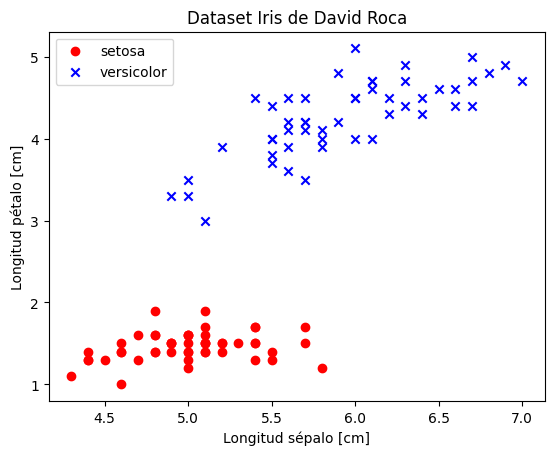

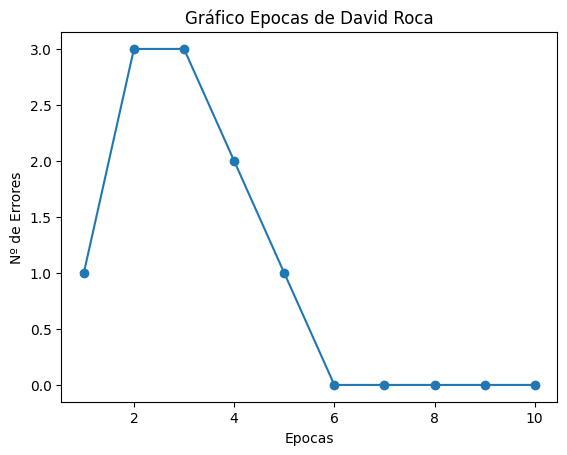

C:\Users\davil\AppData\Local\Temp\ipykernel_10832\1028305405.py:98: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


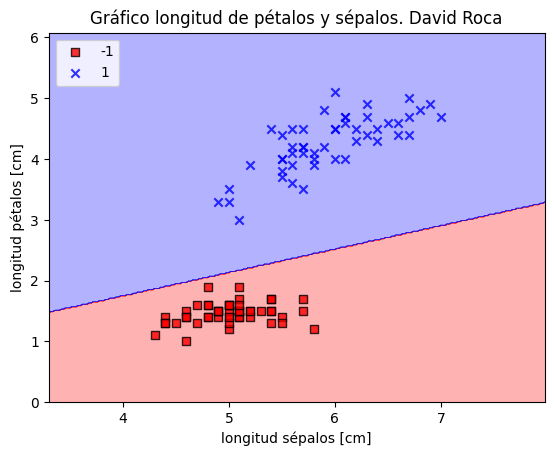

In [28]:
# coding: utf-8
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

class Perceptron(object):
    def __init__(self, eta=0.01, n_iter=50, semilla=1):
        self.eta = eta
        self.n_iter = n_iter
        self.semilla = semilla

    def fit(self, X, y):
        rgen = np.random.RandomState(self.semilla)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=1 + X.shape[1])
        self.errores_ = []
        for _ in range(self.n_iter):
            errores = 0
            for xi, target in zip(X, y):
                incremento = self.eta * (target - self.predict(xi))
                self.w_[1:] += incremento * xi
                self.w_[0] += incremento
                errores += int(incremento != 0.0)
            self.errores_.append(errores)
        return self

    def net_input(self, X):
        return np.dot(X, self.w_[1:]) + self.w_[0]

    def predict(self, X):
        return np.where(self.net_input(X) >= 0.0, 1, -1)

v1 = np.array([1, 2, 3])
v2 = 0.5 * v1
np.arccos(v1.dot(v2) / (np.linalg.norm(v1) * np.linalg.norm(v2)))



# ## PASO 2: PREPARAR EL DATASET

# Leer el dataset: <lugar> puede ser una ruta o una URL
# pd.read('https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data', header=None)
# pd.read('c:\usuarios\manolo\datasets\iris.data', header=None)

lugar = "iris.data"
print("---- Leyendo dataset de:", lugar)
df = pd.read_csv(lugar, header=None, encoding="utf-8")
print("---- Últimos 5 ejemplos:\n", df.tail())



y = df.iloc[0:100, 4].values  # seleccionar ejemplos de setosa y versicolor
y = np.where(y == 'Iris-setosa', -1, 1)  # Codificarlos en +1 (Iris-Versicolor) y -1 (Iris-setosa)
X = df.iloc[0:100, [0, 2]].values  # extraer longitud de sépalos y pétalos

# Dibujar los datos
plt.scatter(X[:50, 0], X[:50, 1], color='red', marker='o', label='setosa')
plt.scatter(X[50:100, 0], X[50:100, 1], color='blue', marker='x', label='versicolor')
plt.xlabel('Longitud sépalo [cm]')
plt.ylabel('Longitud pétalo [cm]')
plt.legend(loc='upper left')
plt.title(loc='center', label='Dataset Iris de David Roca')
plt.show()  # plt.savefig('images/02_06.png', dpi=300)



ppn = Perceptron(eta=0.1, n_iter=10)
ppn.fit(X, y)
plt.plot(range(1, len(ppn.errores_) + 1), ppn.errores_, marker="o")
plt.xlabel("Epocas")
plt.ylabel("Nº de Errores")
plt.title(loc="center", label="Gráfico Epocas de David Roca")
plt.show()  # plt.savefig('images/U02_P01_02.png', dpi=300)



## PASO 4: función para dibujar regiones de decisión
def plot_regiones(X, y, clasificador, resolucion=0.02):
    marcadores = ("s", "x", "o", "^", "v")
    colores = ("red", "blue", "lightgreen", "gray", "cyan")
    cmap = ListedColormap(colores[: len(np.unique(y))])

    # Dibujar la superficie de decisión
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(
        np.arange(x1_min, x1_max, resolucion), np.arange(x2_min, x2_max, resolucion)
    )
    Z = clasificador.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # Dibujar la clase de los ejemplos
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(
            x=X[y == cl, 0],
            y=X[y == cl, 1],
            alpha=0.8,
            c=colores[idx],
            marker=marcadores[idx],
            label=cl,
            edgecolor="black",
        )


# Por último hacemos una llamada a la función para generar el gráfico:
plot_regiones(X, y, clasificador=ppn)
plt.xlabel("longitud sépalos [cm]")
plt.ylabel("longitud pétalos [cm]")
plt.legend(loc="upper left")  # plt.savefig('images/U02_P01_3.png', dpi=300)
plt.title(loc="center", label="Gráfico longitud de pétalos y sépalos. David Roca")
plt.show()

---
# PASO 1: IMPLEMENTAR ADALINE CON GDB EN PYTHON

In [29]:
# coding: utf-8
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

class AdalineGDB(object):
    """Clasificador ADAPtive LInear NEuron de David Roca.

    Parámetros:
    ----------
    eta: float Learning rate (entre 0.0 y 1.0)
    n_iter: int max. repasos que da (iteraciones) al dataset train
    semilla: int; semilla para el GNA

    Atributos:
    ----------
    w_: 1d-array pesos que aprende después de entrenar.
    coste_: lista valores de la función de coste SSE en cada época (repaso)
    """
    def __init__(self, eta=0.01, n_iter=50, semilla=1):
        self.eta = eta
        self.n_iter = n_iter
        self.semilla = semilla

    def fit(self, X, y):
        """ Entrena (Aprende)

        Parámetros:
        ----------
        X: {array}, estructura = [n_ejemplos, n_características]
        y: array, estructura = [n_ejemplos] valores target/label
        
        Devuelve:
        ----------
        self: object
        """
        rgen = np.random.RandomState(self.semilla)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=1 + X.shape[1])  # pesos
        self.coste_ = []
        for i in range(self.n_iter):
            entradas = self.entradas(X)
            salidas = self.activacion(entradas)
            errores = (y - salidas)
            self.w_[1:] += self.eta * X.T.dot(errores)
            self.w_[0] += self.eta * errores.sum()
            coste = (errores**2).sum() / 2.0
            self.coste_.append(coste)
        return self

    def entradas(self, X):
        """Calcula las entradas netas"""
        return np.dot(X, self.w_[1:]) + self.w_[0]

    def predict(self, X):
        """Realiza predicciones"""
        return np.where(self.entradas(X) >= 0.0, 1, -1)

    def activacion(self, X):
        """Calcula la activación lineal"""
        return X


## PREGUNTA 1
### La fórmula de la línea 43 self.eta * errores.sum() es la actualización de:
 - `El bias, el parámetro w0 de la neurona`.
 - El resto de parámetros w1 ... wn de la neurona.

## PREGUNTA 2
### Si eliminamos o comentamos la línea 40 del código
 - No aplicamos la función de activación y la neurona no hará bien su trabajo.
 - `No pasa nada porque al ser la función identidad en realidad no hace falta aplicarla, no hace cambios, se usa para que se vea que la tiene.`

---
# PASO 2: CARGAR DATASET DE PRUEBA

In [30]:
## PASO 2: PREPARAR EL DATASET Y ENTRENAR ADALINE
lugar = "iris.data"
df = pd.read_csv(lugar, header=None, encoding='utf-8')

# Preparar los datos de entrenamiento de Iris
y = df.iloc[0:100, 4].values                     # seleccionar ejemplos de setosa y versicolor
y = np.where(y == 'Iris-setosa', -1, 1)         # Codifica -1 (Iris-setosa) +1 (Iris-versicolor)
X = df.iloc[0:100, [0, 2]].values               # extraer longitud de sépalos y pétalos

---
# PASO 3: ENTRENAR MODELO Y VER GRÁFICA DE FUNCIÓN COSTE

Último coste: 51.08122709777622
Último coste en escala logarítmica: 1.7082613215473657


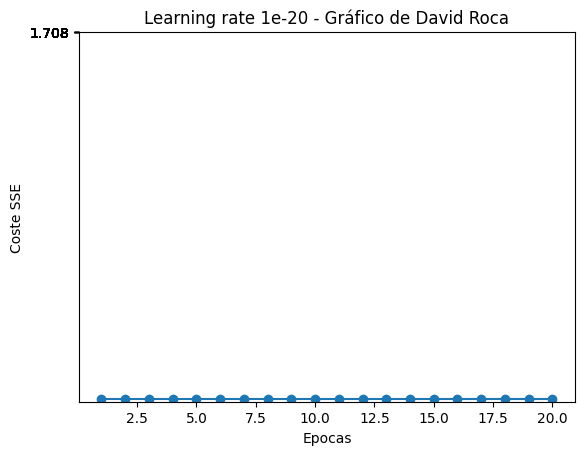

In [31]:
# Entrenar adaline
learning_rate= 0.00000000000000000001
ada1 = AdalineGDB(n_iter=20, eta=learning_rate).fit(X, y)
fig, ax = plt.subplots()
ax.plot(range(1, len(np.log10(ada1.coste_))+1), np.log10(np.log10(ada1.coste_)), marker='o')
ax.set_yticks(np.log10(ada1.coste_))
plt.xlabel('Epocas')
plt.ylabel('Coste SSE')
plt.title(f'Learning rate {learning_rate} - Gráfico de David Roca')

ultimo_coste = ada1.coste_[-1]
ultimo_coste_log = np.log10(ultimo_coste)

print("Último coste:", ada1.coste_[-1])
print("Último coste en escala logarítmica:", ultimo_coste_log)


## PREGUNTA 3
### Entrega el nuevo gráfico y responde:
- ¿Cómo se ve ahora el gráfico? --> Ahora la línea del gráfico se ve curva en lugar de recta, ya que hemos reducido la escala.
- ¿Qué función de coste está usando? (marca una) --> ·`SSE`   ·MSE   ·RMSE   ·GD
- A la vista del gráfico ¿Cuanto más estudia más aprende? --> Al contrario, según el gráfico, cuanto más estudia más errores comete.
- ¿Qué valor de error comete cuando ha estudiado las 20 veces? ¿Y en escala logarítmica? --> El valor de error cuando ha estudiado las 20 veces es `8.895049170892875`. Y en escala logarítmica es: `125.94914835316064`

---
# PASO 4: ENCONTRAR UN VALOR PARA EL LEARNING RATE

Último coste: 51.08122709777622
Último coste en escala logarítmica: 1.7082613215473657


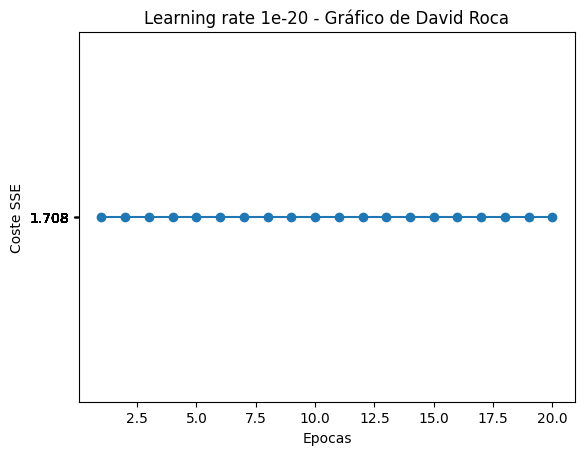

In [32]:
# Entrenar adaline
learning_rate= 0.00000000000000000001
ada1 = AdalineGDB(n_iter=20, eta=learning_rate).fit(X, y)
fig, ax = plt.subplots()
ax.plot(range(1, len(np.log10(ada1.coste_))+1), np.log10(ada1.coste_), marker='o')
ax.set_yticks(np.log10(ada1.coste_))
plt.xlabel('Epocas')
plt.ylabel('Coste SSE')
plt.title(f'Learning rate {learning_rate} - Gráfico de David Roca')

ultimo_coste = ada1.coste_[-1]
ultimo_coste_log = np.log10(ultimo_coste)

print("Último coste:", ada1.coste_[-1])
print("Último coste en escala logarítmica:", ultimo_coste_log)

## PREGUNTA 4
### Indica los valores que has encontrado:
 - Valor del learning rate que hace mínimo el error usando 20 épocas:

El valor del learning rate que hace mínimo el error usando 20 épocas es: `0.00000000000000000001` (Se le pueden añadir más ceros pero ya no influyen).
 
 - ¿Qué valor de error consigues?

Consigo el valor: `51.08122709777622`

---
# PASO 5: PREPROCESAR LOS DATOS ANTES DE ENTRENAR

In [33]:
media_X = np.mean(X, axis=0)  # media de las columnas
desviacion_X = np.std(X, axis=0)
print("medias:", media_X)
print("desviaciones:", desviacion_X)
X_normal = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
# --- Volver a entrenar AdalineGD(), ajustar learning rate y graficar aprendizaje

medias: [5.471 2.862]
desviaciones: [0.63848179 1.44130358]


Último coste: 13.202292352625427
Último coste en escala logarítmica: 1.1206493455740423


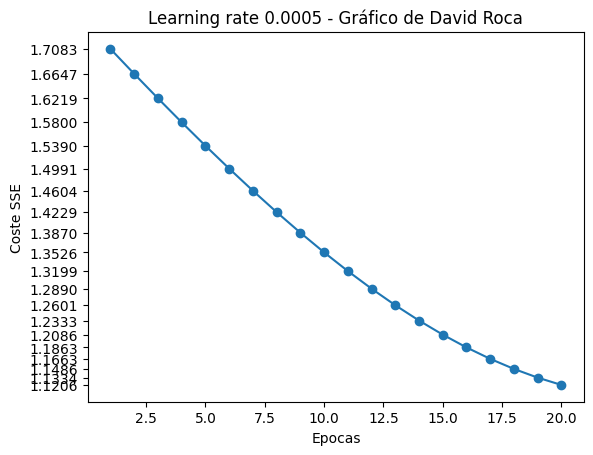

In [34]:
# Entrenar adaline
learning_rate= 0.0005
ada1 = AdalineGDB(n_iter=20, eta=learning_rate).fit(X, y)
fig, ax = plt.subplots()
ax.plot(range(1, len(np.log10(ada1.coste_))+1), np.log10(ada1.coste_), marker='o')
ax.set_yticks(np.log10(ada1.coste_))
plt.xlabel('Epocas')
plt.ylabel('Coste SSE')
plt.title(f'Learning rate {learning_rate} - Gráfico de David Roca')

ultimo_coste = ada1.coste_[-1]
ultimo_coste_log = np.log10(ultimo_coste)

print("Último coste:", ada1.coste_[-1])
print("Último coste en escala logarítmica:", ultimo_coste_log)

## PREGUNTA 5
### Entrega el resultado de la ejecución y responde:
 - Valor del learning rate que hace mínimo el error usando 20 épocas:

    El valor del learning rate que hace mínimo el error usando 20 épocas es: `0.00000000000000000001`

 - ¿Qué valor de error consigues?

    Asignando el valor 0.5 al learning rate, obtengo el valor de error: `8.895049170892875`

 - ¿Mejor o peor si escalas las características?

    Es mejor si las escalo, porque el Descenso por Gradiente aprende más rápido.
 
 - Marca las opciones que sean ciertas:
    - `Con características escaladas el Descenso por Gradiente aprende más rápido.`
    - `Para la misma cantidad de entrenamiento (estudio) el Descenso por Gradiente aprende más con características escaladas.`
    - `El learning rate puede ser mayor con características escaladas.`

    (En mi opinión, todas)

---
# PASO 5: MOSTRAR FRONTERA DE DECISIÓN

In [35]:
# ## PASO 5: función para dibujar regiones de decisión
def plot_regiones(X, y, clasificador, resolucion=0.02):
    marcadores = ("s", "x", "o", "^", "v")
    colores = ("red", "blue", "lightgreen", "gray", "cyan")
    cmap = ListedColormap(colores[: len(np.unique(y))])

    # Dibujar la superficie de decisión
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(
        np.arange(x1_min, x1_max, resolucion), np.arange(x2_min, x2_max, resolucion)
    )
    Z = clasificador.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # Dibujar la clase de los ejemplos
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(
            x=X[y == cl, 0],
            y=X[y == cl, 1],
            alpha=0.8,
            c=colores[idx],
            marker=marcadores[idx],
            label=cl,
            edgecolor="black",
        )

C:\Users\davil\AppData\Local\Temp\ipykernel_10832\2064824751.py:21: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


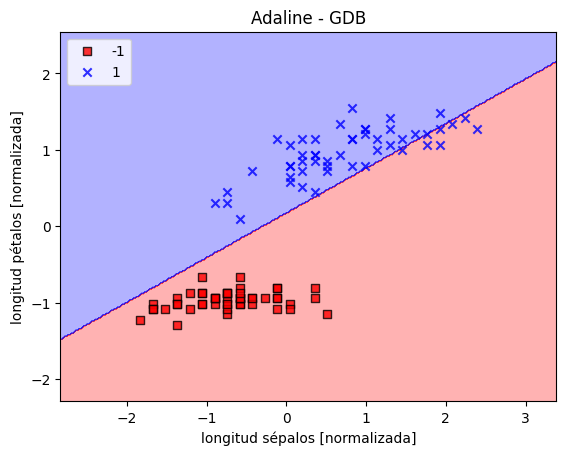

In [36]:
# Dibujar el gráfico
plot_regiones(X_normal, y, clasificador=ada1)

plt.xlabel("longitud sépalos [normalizada]")
plt.ylabel("longitud pétalos [normalizada]")
plt.legend(loc="upper left")
plt.title("Adaline - GDB")
plt.show()

# Este es el mejor gráfico que he podido realizar ajustando el learning rate.

---
# ACTIVIDAD 2. MEJORAS PARA MUCHOS DATOS: DGS

## PREGUNTA 6
### Copia el código de AdalineDGB.py en AdalineDGS.py (o a otra celda del notebook).

In [37]:
# coding: utf-8
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

class AdalineDGS(object):
    """Clasificador ADAPtive LInear NEuron de David Roca.

    Parámetros:
    ----------
    eta: float Learning rate (entre 0.0 y 1.0)
    n_iter: int max. repasos que da (iteraciones) al dataset train
    semilla: int; semilla para el GNA

    Atributos:
    ----------
    w_: 1d-array pesos que aprende después de entrenar.
    coste_: lista valores de la función de coste SSE en cada época (repaso)
    """
    def __init__(self, eta=0.01, n_iter=50, semilla=1, desordenado = True):
        self.eta = eta
        self.n_iter = n_iter
        self.semilla = semilla
        self.desordenado = desordenado
        self.w_inicializado = False


    def fit(self, X, y):
        """
        Entrena (Aprende)

        Parámetros:
        ----------
        X: {array}, estructura = [n_ejemplos, n_características]
        y: {array}, estructura = [n_ejemplos] valores target/label

        Devuelve:
        ---------
        self: object
        """
        self._inicializa_pesos(X.shape[1])
        self.coste_ = []
        for i in range(self.n_iter):
            if self.desordenado:
                X, y = self._desordena(X, y)
            coste = []
            for xi, target in zip(X, y):
                coste.append(self._actualiza_pesos(xi, target))
            costeMedio = sum(coste) / len(y)
            self.coste_.append(costeMedio)
        return self

    def parcial_fit(self, X, y):  # Entrena sin reordenar
        if not self.w_inicializado:
            self._inicializa_pesos(X.shape[1])
        if y.ravel().shape[0] > 1:
            for xi, target in zip(X, y):
                self._actualiza_pesos(xi, target)
        else:
            self._actualiza_pesos(X, y)
        return self

    def _desordena(self, X, y):
        r = self.rgen.permutation(len(y))
        return X[r], y[r]

    def _inicializa_pesos(self, m):
        self.rgen = np.random.RandomState(self.semilla)
        self.w_ = self.rgen.normal(loc=0.0, scale=0.01, size=1 + m)
        self.w_inicializado = True

    def _actualiza_pesos(self, xi, target):
        salida = self.activacion(self.entradas(xi))
        error = target - salida
        self.w_[1:] += self.eta * xi.dot(error)
        self.w_[0] += self.eta * error
        coste = 0.5 * error**2
        return coste
    
    def predict(self, X):
        """Realiza predicciones"""
        return np.where(self.entradas(X) >= 0.0, 1, -1)
    
    def entradas(self, X):
        return np.dot(X, self.w_[1:]) + self.w_[0]

    def activacion(self, Z):
        return Z  # Función de identidad para Adaline


## PREGUNTA 7
### Actualiza el código y lo adaptas para crear y entrenar un objeto AdalineDGS que tenga 15 iteraciones y un learning rate de 0.01, repite lo mismo que hicimos con AdalineDGB y me pasas los gráficos de las regiones y el entrenamiento.

Último coste: 0.03203718247038334
Último coste en escala logarítmica: -1.494345685202354


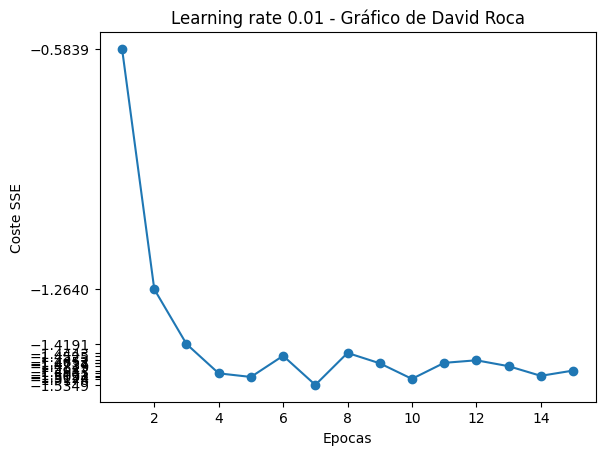

In [38]:
# Entrenar adaline
learning_rate= 0.01
ada2 = AdalineDGS(n_iter=15, eta=learning_rate).fit(X, y)
fig, ax = plt.subplots()
ax.plot(range(1, len(np.log10(ada2.coste_))+1), np.log10(ada2.coste_), marker='o')
ax.set_yticks(np.log10(ada2.coste_))
plt.xlabel('Epocas')
plt.ylabel('Coste SSE')
plt.title(f'Learning rate {learning_rate} - Gráfico de David Roca')

ultimo_coste = ada2.coste_[-1]
ultimo_coste_log = np.log10(ultimo_coste)

print("Último coste:", ada2.coste_[-1])
print("Último coste en escala logarítmica:", ultimo_coste_log)

In [39]:
lugar = "iris.data"
df = pd.read_csv(lugar, header=None, encoding='utf-8')

# Preparar los datos de entrenamiento de Iris
y = df.iloc[0:100, 4].values                     # seleccionar ejemplos de setosa y versicolor
y = np.where(y == 'Iris-setosa', -1, 1)         # Codifica -1 (Iris-setosa) +1 (Iris-versicolor)
X = df.iloc[0:100, [0, 2]].values  

In [ ]:
media_X = np.mean(X, axis=0)  # media de las columnas
desviacion_X = np.std(X, axis=0)
print("medias:", media_X)
print("desviaciones:", desviacion_X)
# Fórmula original
#X_normal = X - media_X / desviacion_X
X_normal = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

# --- Volver a entrenar AdalineGD(), ajustar learning rate y graficar aprendizaje

medias: [5.471 2.862]
desviaciones: [0.63848179 1.44130358]


In [41]:
def plot_regiones(X, y, clasificador, resolucion=0.02):
    marcadores = ("s", "x", "o", "^", "v")
    colores = ("red", "blue", "lightgreen", "gray", "cyan")
    cmap = ListedColormap(colores[: len(np.unique(y))])

    # Dibujar la superficie de decisión
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(
        np.arange(x1_min, x1_max, resolucion), np.arange(x2_min, x2_max, resolucion)
    )
    Z = clasificador.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # Dibujar la clase de los ejemplos
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(
            x=X[y == cl, 0],
            y=X[y == cl, 1],
            alpha=0.8,
            c=colores[idx],
            marker=marcadores[idx],
            label=cl,
            edgecolor="black",
        )

C:\Users\davil\AppData\Local\Temp\ipykernel_10832\3190699880.py:20: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(


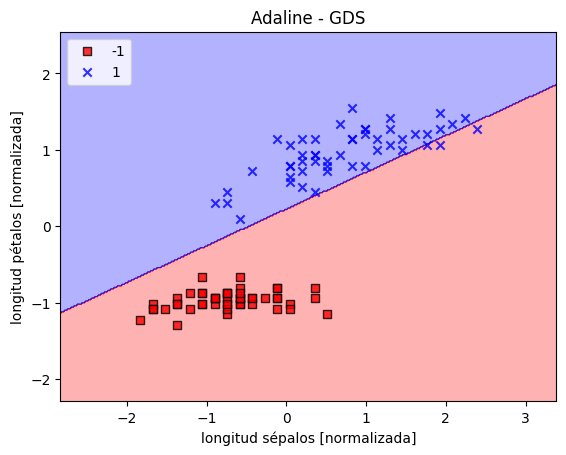

In [42]:
# Dibujar el gráfico
plot_regiones(X_normal, y, clasificador=ada2)

plt.xlabel("longitud sépalos [normalizada]")
plt.ylabel("longitud pétalos [normalizada]")
plt.legend(loc="upper left")
plt.title("Adaline - GDS")
plt.show()

---
# ACTIVIDAD 3. USAR MODELOS YA PROGRAMADOS

In [43]:
# -*- coding: utf-8 -*-
from sklearn import datasets
import numpy as np

iris = datasets.load_iris()
X = iris.data[:, [2, 3]]
y = iris.target
print('Diferentes clases:', np.unique(y))

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)

print('Contar Labels en y:', np.bincount(y))
print('Contar Labels en y_train:', np.bincount(y_train))
print('Contar Labels en y_test:', np.bincount(y_test))

Diferentes clases: [0 1 2]
Contar Labels en y: [50 50 50]
Contar Labels en y_train: [35 35 35]
Contar Labels en y_test: [15 15 15]


## PREGUNTA 8
### Marca las respuestas sobre estos parámetros de la función train_test_split():
El parámetro ramdon_state=valor nos va a permitir:
 - `Que si ejecutamos dos veces el código, dará los mismos resultados porque inicializa todo lo que ocurra de manera aleatoria al mismo valor.`
 - Que todo ocurra de manera impredecible y difícil de repetir.

El parámetro stratify = y nos va a permitir:
 - `Que los datos queden balanceados, que tengan cantidades similares de cada clase.`
 - Que los ejemplos se cojan en grupos como si formasen estratos.
 
El parámetro size = 0.3 nos va a permitir:
 - Que el 30% de los datos se usan para entrenar.
 - `Que el 30% de los datos se usan para testar el modelo.`
 - Que no se cogen el 30% de los datos para mejorar la aleatoriedad de los datos.

In [44]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
sc.fit(X_train)
X_train_normalizado = sc.transform(X_train)
X_test_normalizado = sc.transform(X_test)

In [45]:
def plot_regiones(X, y, clasificador, test_idx=None, resolucion=0.02):
    markers = ('s', 'x', 'o', '^', 'v')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])
    
    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolucion),
                           np.arange(x2_min, x2_max, resolucion))
    Z = clasificador.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())
    
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1],
                    alpha=0.8, c=colors[idx],
                    marker=markers[idx], label=cl, edgecolor='black')
    
    # highlight test samples
    if test_idx:
        X_test, y_test = X[test_idx, :], y[test_idx]
        plt.scatter(X_test[:, 0], X_test[:, 1], c='y', edgecolor='black',
                    alpha=1.0, linewidth=1, marker='o', s=100, label='test')

C:\Users\davil\AppData\Local\Temp\ipykernel_10832\1430023324.py:18: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1],


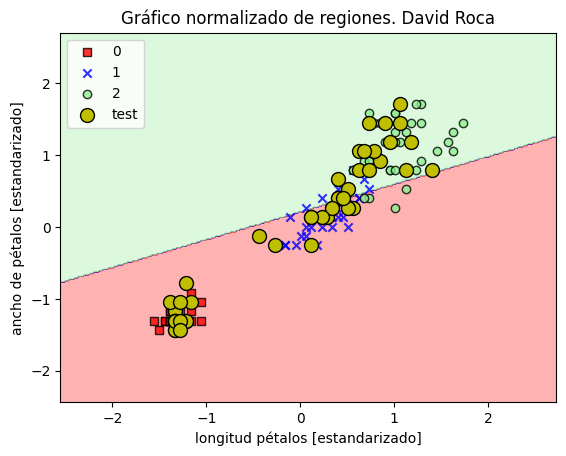

In [46]:
X_combined_std = np.vstack((X_train_normalizado, X_test_normalizado))
y_combined = np.hstack((y_train, y_test))

plot_regiones(X=X_combined_std, y=y_combined, clasificador=ppn, test_idx=range(105, 150))
plt.xlabel('longitud pétalos [estandarizado]')
plt.ylabel('ancho de pétalos [estandarizado]')
plt.legend(loc='upper left')
plt.title("Gráfico normalizado de regiones. David Roca")
plt.show()

## PREGUNTA 9
### Escribe el código y lo ejecutas. Cuando generes el gráfico, añade tu nombre al título y añade la sentencia que lo guarde en el fichero U02_P02_09.png.
Se encuentra arriba.